In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

In [2]:
df = pd.read_csv('data.csv')
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

In [3]:
df['text_lemma'] = df['text_lemma'].astype(str)

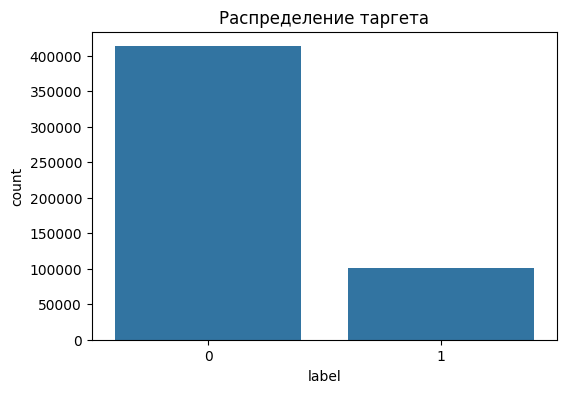

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Распределение таргета')
plt.show()

In [5]:
df['label'].value_counts()

label
0    413314
1    100517
Name: count, dtype: int64

In [6]:
df['label'].value_counts(normalize=True)

label
0    0.804377
1    0.195623
Name: proportion, dtype: float64

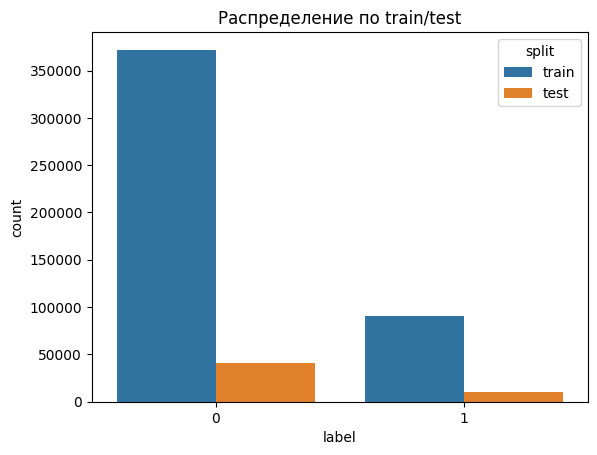

In [7]:
train_df['split'] = 'train'
test_df['split'] = 'test'

temp = pd.concat([train_df, test_df])

sns.countplot(data=temp, x='label', hue='split')
plt.title('Распределение по train/test')
plt.show()

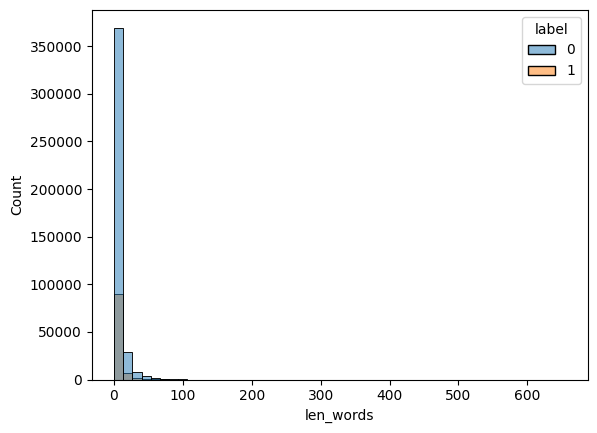

In [8]:
df['len_words'] = df['text_lemma'].apply(lambda x: len(x.split()))

sns.histplot(data=df, x='len_words', hue='label', bins=50)
plt.show()

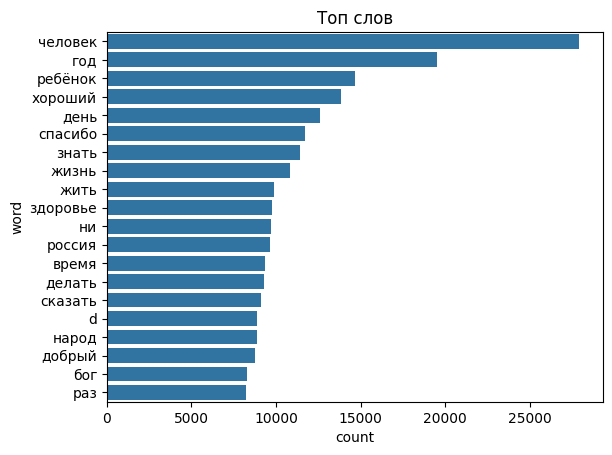

In [9]:
all_words = " ".join(df['text_lemma']).lower().split()
counter = Counter(all_words)

top_words = pd.DataFrame(counter.most_common(20), columns=['word','count'])

sns.barplot(data=top_words, x='count', y='word')
plt.title('Топ слов')
plt.show()

In [10]:
for t in df['label'].unique():
    words = " ".join(df[df['label']==t]['text_lemma']).lower().split()
    counter = Counter(words)
    print(f"\nКласс {t}")
    print(counter.most_common(10))


Класс 0
[('человек', 22937), ('год', 17657), ('хороший', 12395), ('ребёнок', 11987), ('день', 11904), ('спасибо', 11516), ('здоровье', 9600), ('знать', 9511), ('жизнь', 9283), ('добрый', 8611)]

Класс 1
[('тварь', 5559), ('человек', 4993), ('пидор', 4482), ('мразь', 3355), ('сука', 3350), ('d', 3123), ('народ', 2990), ('хуй', 2989), ('урод', 2963), ('россия', 2875)]


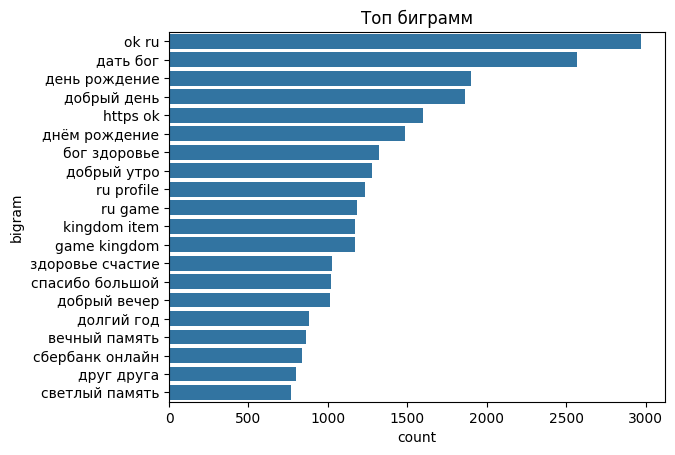

In [11]:
cv = CountVectorizer(ngram_range=(2,2), max_features=20)
X_bi = cv.fit_transform(df['text_lemma'])

bigrams = pd.DataFrame({
    'bigram': cv.get_feature_names_out(),
    'count': X_bi.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

sns.barplot(data=bigrams, x='count', y='bigram')
plt.title('Топ биграмм')
plt.show()